# PCA - PRINCIPAL COMPONENT ANALYSIS

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Import visualization packages.
import seaborn as sns
import matplotlib.pyplot as plt

#PCA
from sklearn.decomposition import PCA

PCA is useful to get insights about which variables contribute the most to variance.  In this case, PCA will be performed on our enginerred dataset.
  
PCA needs standardized variables. Hence, the engineered dataset is loaded and then scaled.

In [3]:
#load the dataset
df = pd.read_csv("../data/crypto_volatility_fe.csv")
#show it
print('Original dataset first 5 rows:')
print(df.head())
print()

#define the scaler
scaler = StandardScaler()
#drop date
df_scaled = df.drop(columns = ["date"])
#get columns names
var_names = df_scaled.columns.tolist()
#scale the dataset
df_scaled = scaler.fit_transform(df_scaled)
#convert to a df
df_scaled = pd.DataFrame(df_scaled, columns = var_names)
#show the scaled dataset
print('Scaled dataset first 5 rows:')
print(df_scaled.head())

Original dataset first 5 rows:
         date    close         volume  trend  fg_index  cluster  log_return  \
0  2018-02-06  7652.14  100201.500307     78       8.0        5    0.097685   
1  2018-02-07  7599.00   60778.460497     49      36.0        0   -0.006969   
2  2018-02-08  7784.02    1521.537318     41      30.0        0    0.024056   
3  2018-02-09  8683.92   20482.910825     35      44.0        0    0.109400   
4  2018-02-10  8533.98   49381.512653     28      54.0        0   -0.017417   

   hl_spread  momentum_3    vol_change  rolling_std_5  volatility  
0    1877.99    -1547.82  36798.317728       0.107546    0.062370  
1    1325.99     -585.81 -39423.039810       0.108378    0.072188  
2     271.91      844.03 -59256.923179       0.106621    0.079527  
3     948.10     1031.78  18961.373507       0.110290    0.077253  
4     945.78      934.98  28898.601828       0.058932    0.076113  

Scaled dataset first 5 rows:
      close    volume     trend  fg_index   cluster  log

Once the dataset is standardized, it is possible to apply PCA. PCA helps in understanding how much variance (i.e changes) each principal compoenets explains.

In [ ]:
#initilize PCA
pca = PCA()
#fit PCA on the scaled df
pca.fit(df_scaled)
#transform data
df_pca = pca.transform(df_scaled)

During the PCA process, it is fundamental to identify how many components (PCs) should be kept. The explained variance ratio guides this decision.  
  
To do that, let's build the scree plot.

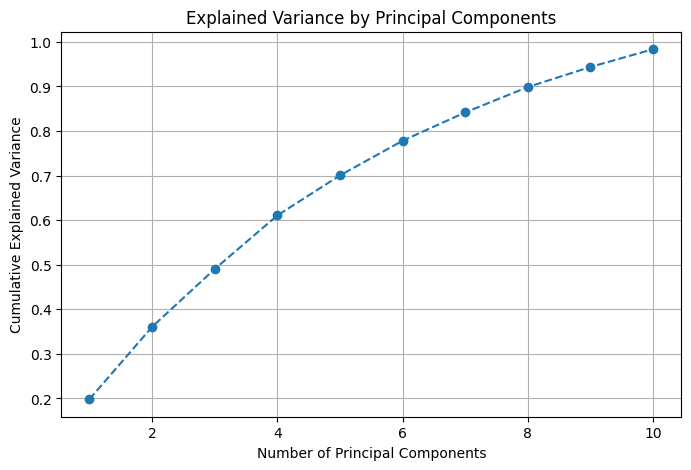

In [7]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

The chart shows how the variance explained increases with PCs without experiencing drastic swings.  
  
Let's set an arbitrary threshold of 75% of variance explained and check how many PCs are needed. According to the chart, they should be either 6 or 7.

In [13]:
# Keep components that explain 90% of variance
pca = PCA(n_components=0.75)
df_pca_reduced = pca.fit_transform(df_scaled)
#print the PCA shape
print(f'Shape after PCA: {df_pca_reduced.shape}')

Shape after PCA: (2634, 6)


The df has now been reduced to 6 PCs. However, this is not that useful considered alone.   
Let's focus on the df variables and display how much each single variable contributes to each PC

In [15]:
#define the entire variables
features = var_names
# build a df for PCA components
# Create a DataFrame for PCA component loadings (feature importance)
pca_components = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
print(pca_components)

        close    volume     trend  fg_index   cluster  log_return  hl_spread  \
PC1  0.510608  0.142183  0.445968  0.298552  0.016109    0.012424   0.598967   
PC2 -0.311022  0.409666  0.180930 -0.360934  0.118195   -0.283210   0.020780   
PC3 -0.239700  0.182555  0.111333  0.069617  0.345890    0.566319  -0.135646   
PC4  0.070524 -0.485280 -0.218244  0.240340  0.502861   -0.201240   0.080322   
PC5 -0.180443  0.079271 -0.130475  0.391101  0.460769   -0.191694  -0.057888   
PC6  0.131975 -0.296785 -0.462155 -0.241830 -0.292868    0.237077   0.175762   

     momentum_3  vol_change  rolling_std_5  volatility  
PC1    0.067214    0.163976       0.178295    0.093131  
PC2   -0.346952    0.171431       0.431452    0.376704  
PC3    0.570147   -0.052058       0.267923    0.183462  
PC4   -0.149634   -0.369709       0.225022    0.380273  
PC5   -0.008236    0.671458      -0.289096   -0.065332  
PC6    0.108882    0.499398       0.121130    0.416697  


To conlude, let's inspect the 3 variables contributing the most to each PCs.

In [16]:
#show the most contributing variables for each PC
print("\nTop 3 contributing features for each Principal Component:\n")
for i, comp in enumerate(pca_components.values):
    top_features = np.argsort(np.abs(comp))[-3:][::-1]  # Top 3 features
    feature_names = pca_components.columns[top_features]
    feature_importance = np.abs(comp[top_features])  # Get actual importance values
    print(f'PC{i+1}:')
    for feat, imp in zip(feature_names, feature_importance):
        print(f'  - {feat} ({imp:.4f})')  # Display feature importance rounded to 4 decimals
    print("")


Top 3 contributing features for each Principal Component:

PC1:
  - hl_spread (0.5990)
  - close (0.5106)
  - trend (0.4460)

PC2:
  - rolling_std_5 (0.4315)
  - volume (0.4097)
  - volatility (0.3767)

PC3:
  - momentum_3 (0.5701)
  - log_return (0.5663)
  - cluster (0.3459)

PC4:
  - cluster (0.5029)
  - volume (0.4853)
  - volatility (0.3803)

PC5:
  - vol_change (0.6715)
  - cluster (0.4608)
  - fg_index (0.3911)

PC6:
  - vol_change (0.4994)
  - trend (0.4622)
  - volatility (0.4167)



The PCA offers several valuable insights:  
  
- The first three principal components alone account for approximately 50% of the total variance, indicating they capture much of the dataset’s underlying structure.
Among these, the most influential features are hl_spread (PC1), rolling_std_5 (PC2), and momentum_3 (PC3).
- cluster appears in multiple components, suggesting it captures complex relationships and reinforces its inclusion in the dataset.
- Since every feature contributes meaningfully to at least one principal component, it indicates that all engineered variables are relevant to explaining crypto market dynamics.  
  
To sum up, the PCA underscores the effectiveness of the feature engineering process. It also highlights the difficulty of reducing crypto complexity into a few dimensions, confirming that most features may hold predictive value for downstream modeling